### Init

In [2]:
import sys
sys.path.append('../')

import torch
import json

from src.model import Transformer, generate_batch
from src.dataset import (
    NMRDataset, 
    load_multiplicity_codes, 
    load_split, 
    collate_fn
)

import sentencepiece as spm

from functools import partial

In [3]:
tokenizer = spm.SentencePieceProcessor('../checkpoints/nmr2struct.model')

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
print(device)

cuda


In [6]:
model = Transformer(
    multiplicity_vocab_size=len(NMRDataset.MULTIPLICITY2IDX),
    multiplicity_hidden_dim=48,
    spectrum_d_ff=256,
    spectrum_hidden_dim=104,
    intensity_d_ff=256,
    intensity_hidden_dim=104,
    tgt_vocab_size=tokenizer.vocab_size(),
    d_model=256,
    num_heads=8,
    num_layers=6,
    d_ff=512,
    max_seq_length=400,
    dropout=0.2,
    smiles_pad_token=tokenizer.pad_id(),
)
model.load_state_dict(torch.load('../checkpoints/bimodal_256_new_data_full_155.pt', map_location=device))
model = model.to(device)
model.eval()

/tmp/ipykernel_512506/751093416.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../checkpoints/bimodal_256_new_data_full_155.pt', map_

Transformer(
  (spectrum_embedding): SpectrumEmbedding(
    (spectrum_embs): ModuleDict(
      (C_NMR): FourierEmbedding(
        (proj): Linear(in_features=256, out_features=104, bias=True)
      )
      (H_NMR): FourierEmbedding(
        (proj): Linear(in_features=256, out_features=104, bias=True)
      )
    )
    (intensity_embs): ModuleDict(
      (C_NMR): FourierEmbedding(
        (proj): Linear(in_features=256, out_features=104, bias=True)
      )
      (H_NMR): FourierEmbedding(
        (proj): Linear(in_features=256, out_features=104, bias=True)
      )
    )
    (multiplicity_embs): ModuleDict(
      (C_NMR): Embedding(10, 48)
      (H_NMR): Embedding(10, 48)
    )
  )
  (decoder_embedding): Embedding(512, 256)
  (positional_encoding): PositionalEncoding()
  (encoder_carbon_layers): ModuleList(
    (0-5): 6 x EncoderLayer(
      (self_attn): MultiHeadAttention(
        (W_q): Linear(in_features=256, out_features=256, bias=True)
        (W_k): Linear(in_features=256, out_featu

In [7]:
multiplicity_codes = load_multiplicity_codes('../data/multiplicity_codes.json')

In [8]:
test_data = load_split(
    path='../data/test_full_50k.jsonl', 
    multiplicity_codes=multiplicity_codes,
    solvent='CDCl3' # Так собраны данные
)

Loading test_full_50k.jsonl: 0it [00:00, ?it/s]

Processing spectra:   0%|          | 0/9954 [00:00<?, ?it/s]

In [9]:
# Для каждой молекулы есть разное количество 1H и 13C спектров
# Датасет устроен так что он каждый раз выдает случайную пару спектров
# И с вероятностью 20% маскирует один из спектров
# Если хочется работать иначе с этим - см. src/dataset.py L153

test_dataset = NMRDataset(
    data=test_data,
    solvent='CDCl3',
    tokenizer=tokenizer,
    smiles_bos_id=tokenizer.bos_id(),
    smiles_eos_id=tokenizer.eos_id(),
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    shuffle=False, 
    batch_size=16, 
    collate_fn=partial(
        collate_fn, 
        smiles_pad_id=tokenizer.pad_id(),
        spectrum_pad_token=-1000.,
        max_smiles_len=400
    )
)

### Deprecated

In [ ]:
from tqdm.auto import tqdm

all_predictions = []
all_true_smiles = []

for data in tqdm(test_loader):
    predictions = generate_batch(
        model=model,
        src_c_nmr=data["C_NMR"],
        src_h_nmr=data["H_NMR"],
        tokenizer=tokenizer,
        max_tokens=400,
        device=device,
    )

    true_smiles = tokenizer.decode(data["smiles"].squeeze().numpy().tolist())

    all_predictions.extend(predictions)
    all_true_smiles.extend(true_smiles)

In [ ]:
import json

assert len(all_predictions) == len(all_true_smiles)

results = [
    {"true_smiles": t, "predicted_smiles": p}
    for t, p in zip(all_true_smiles, all_predictions)
]

with open("test_predictions.json", "w") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

In [ ]:
for pred_smiles, true_smiles in zip(all_predictions[:20], all_true_smiles[:20]):
    print(f"True SMILES: {true_smiles}", f"Predicted SMILES: {pred_smiles}", sep="\t")

True SMILES: O=C1OC(=O)c2ccccc21	Predicted SMILES: O=C1c2ccccc2C(=O)N1Cl
True SMILES: Clc1nc(Cl)c2ccccc2n1	Predicted SMILES: O=C(Cl)c1nc2ccccc2s1
True SMILES: c1ccc2c(N3CCCC3)ncnc2c1	Predicted SMILES: c1ccc2c(N3CCCC3)ncnc2c1
True SMILES: COc1ccc(C=O)cc1OC	Predicted SMILES: COc1ccc(C=O)cc1OC
True SMILES: COc1cc(C(O)c2cc(C3OCC(C)(C)CO3)cc(OC)c2OC)ccc1OCc1ccccc1	Predicted SMILES: COc1cc([C@H](O)c2cc(OC)c(OCc3ccccc3)cc2C2OCC(C)(C)CO2)ccc1OC
True SMILES: O=C(/C=C/C=C/c1ccc(F)cc1)Oc1cccc2cccc(OC(=O)/C=C/C=C/c3ccc(F)cc3)c12	Predicted SMILES: O=C1c2ccccc2C2(c3ccccc3)N(c3ccccc3)c3ccccc3C12c1ccccc1
True SMILES: CC(C)(C)OC(=O)N[C@H]1c2ccccc2C=C[C@H]1c1ccc(Cl)cc1	Predicted SMILES: CC(C)(C)OC(=O)N[C@H]1c2ccccc2C=C[C@@H]1c1ccc(Cl)cc1
True SMILES: CC(C)(C)OC(=O)N[C@H]1c2ccccc2C=C[C@H]1c1ccc(Br)cc1	Predicted SMILES: CC(C)(C)OC(=O)N[C@H]1c2ccccc2C=C[C@@H]1c1ccc(Br)cc1
True SMILES: CC(C)(C)OC(=O)N[C@H]1c2ccccc2C=C[C@H]1c1ccc([N+](=O)[O-])cc1	Predicted SMILES: CC(C)(C)OC(=O)N[C@H]1c2ccccc2C=C[C@H]1c1ccc(

In [ ]:
from rdkit import Chem
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

def canonicalize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)

canon_true = [canonicalize_smiles(s) for s in all_true_smiles]
canon_pred = [canonicalize_smiles(s) for s in all_predictions]

valid_pred = sum(s is not None for s in canon_pred) / len(canon_pred)
canon_exact_match = sum(p == t for p, t in zip(canon_pred, canon_true)) / len(canon_true)

In [26]:
print("Validity:", valid_pred)
print("Canonical exact match:", canon_exact_match)

Validity: 0.9939722724532851
Canonical exact match: 0.39893510146674704


### New

In [10]:
print("model" in globals())
print("test_loader" in globals())
print("tokenizer" in globals())
print("device" in globals())

True
True
True
True


In [11]:
import sys, importlib
import numpy as np
sys.path.insert(0, "/mnt/data")

import noise_quantile_experiment as nqe
importlib.reload(nqe)

<module 'noise_quantile_experiment' from '/home/adaniyarov/Latent_spaces/examples/noise_quantile_experiment.py'>

In [12]:
from tqdm.auto import tqdm
import pandas as pd

def run_noise_quantile_experiment_with_tqdm(
    model,
    dataloader,
    tokenizer,
    device,
    cfg,
    noise_modes=("all",),
):
    nqe.seed_everything(cfg.seed)
    model.eval()

    sample_parts = []
    layerwise_parts = []

    iterable = enumerate(dataloader)
    if cfg.max_batches is not None:
        iterable = list(iterable)[:cfg.max_batches]

    iterable = tqdm(iterable, desc="Batches", total=cfg.max_batches if cfg.max_batches is not None else None)

    for batch_idx, batch in iterable:
        for noise_mode in noise_modes:
            for alpha in tqdm(cfg.alpha_grid, desc=f"alpha ({noise_mode})", leave=False):
                for rep in range(cfg.repeats):
                    sample_df_part, layerwise_df_part = nqe.evaluate_one_batch_under_noise(
                        model=model,
                        batch=batch,
                        tokenizer=tokenizer,
                        device=device,
                        alpha=alpha,
                        cfg=cfg,
                        noise_mode=noise_mode,
                    )
                    sample_df_part["batch_idx"] = batch_idx
                    sample_df_part["rep"] = rep
                    sample_parts.append(sample_df_part)

                    layerwise_df_part["batch_idx"] = batch_idx
                    layerwise_df_part["rep"] = rep
                    layerwise_parts.append(layerwise_df_part)

    sample_long_df = pd.concat(sample_parts, ignore_index=True)
    layerwise_long_df = pd.concat(layerwise_parts, ignore_index=True)
    return sample_long_df, layerwise_long_df

In [13]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [14]:
cfg = nqe.default_noise_config()
cfg.alpha_grid = [round(x, 2) for x in np.linspace(0.0, 0.40, 21)]
cfg.repeats = 10
cfg.max_batches = 15

sample_long_df, layerwise_long_df = run_noise_quantile_experiment_with_tqdm(
    model=model,
    dataloader=test_loader,
    tokenizer=tokenizer,
    device=device,
    cfg=cfg,
    noise_modes=("all",),
)

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

alpha (all):   0%|          | 0/21 [00:00<?, ?it/s]

alpha (all):   0%|          | 0/21 [00:00<?, ?it/s]

alpha (all):   0%|          | 0/21 [00:00<?, ?it/s]

alpha (all):   0%|          | 0/21 [00:00<?, ?it/s]

...

alpha (all):   0%|          | 0/21 [00:00<?, ?it/s]

alpha (all):   0%|          | 0/21 [00:00<?, ?it/s]

alpha (all):   0%|          | 0/21 [00:00<?, ?it/s]

alpha (all):   0%|          | 0/21 [00:00<?, ?it/s]

alpha (all):   0%|          | 0/21 [00:00<?, ?it/s]

In [15]:
tanimoto_summary = nqe.summarize_quantiles(
    sample_long_df,
    metric="tanimoto",
    quantiles=(0.05, 0.25, 0.5, 0.75, 0.95),
)

latent_summary = nqe.summarize_quantiles(
    sample_long_df,
    metric="latent_l2",
    quantiles=(0.05, 0.25, 0.5, 0.75, 0.95),
)

valid_summary = nqe.summarize_binary_rate(
    sample_long_df,
    metric="valid",
)

layerwise_summary = nqe.summarize_layerwise_quantiles(
    layerwise_long_df,
    quantiles=(0.05, 0.25, 0.5, 0.75, 0.95),
)

Matplotlib is building the font cache; this may take a moment.


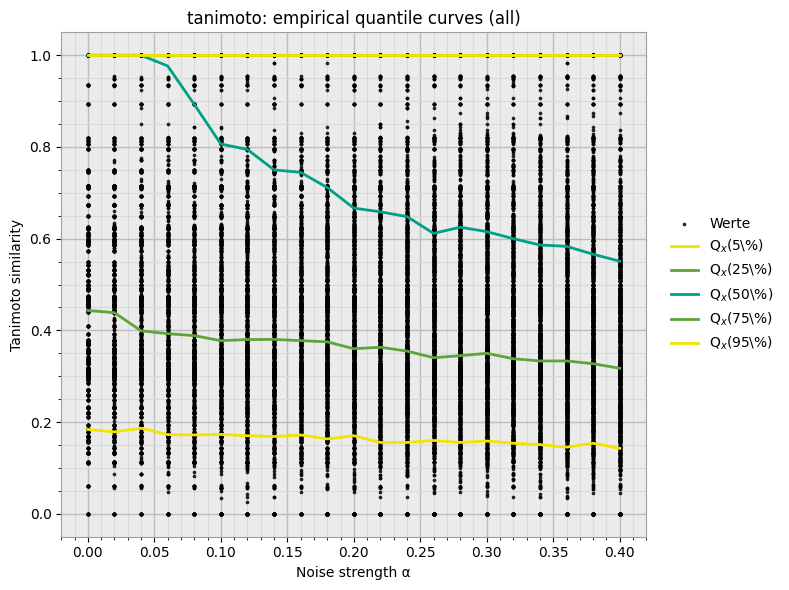

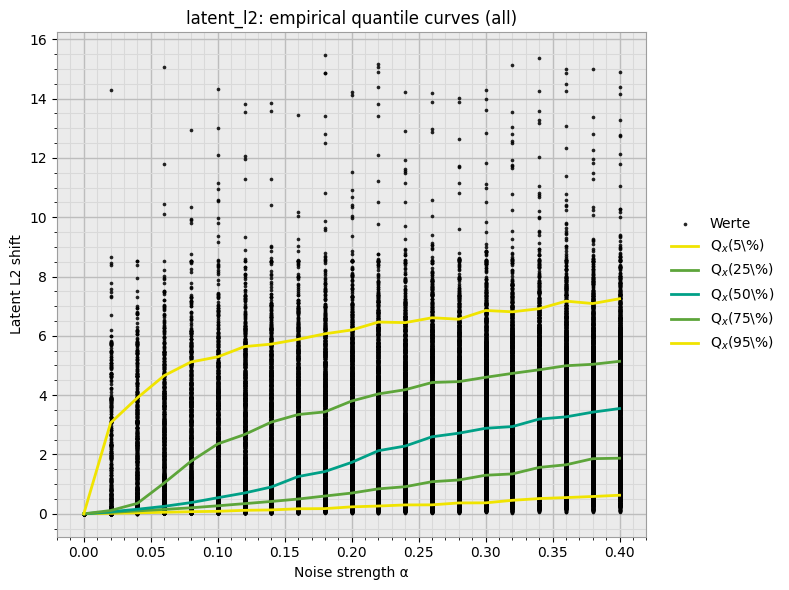

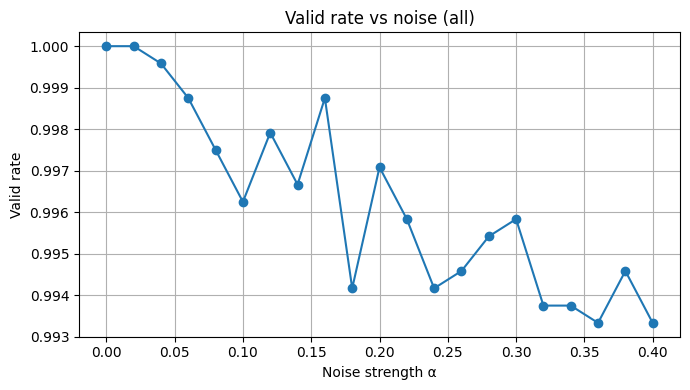

In [18]:
nqe.plot_quantile_scatter_style(
    long_df=sample_long_df,
    metric="tanimoto",
    noise_mode="all",
    quantiles=(0.05, 0.25, 0.5, 0.75, 0.95),
    ylabel="Tanimoto similarity",
)

nqe.plot_quantile_scatter_style(
    long_df=sample_long_df,
    metric="latent_l2",
    noise_mode="all",
    quantiles=(0.05, 0.25, 0.5, 0.75, 0.95),
    ylabel="Latent L2 shift",
)

nqe.plot_binary_rate(
    valid_summary,
    metric_name="Valid rate",
    noise_mode="all",
)

In [19]:
sample_long_df.to_csv("sample_long_df_all.csv", index=False)
layerwise_long_df.to_csv("layerwise_long_df_all.csv", index=False)

tanimoto_summary.to_csv("tanimoto_summary_all.csv", index=False)
latent_summary.to_csv("latent_summary_all.csv", index=False)
valid_summary.to_csv("valid_summary_all.csv", index=False)
layerwise_summary.to_csv("layerwise_summary_all.csv", index=False)

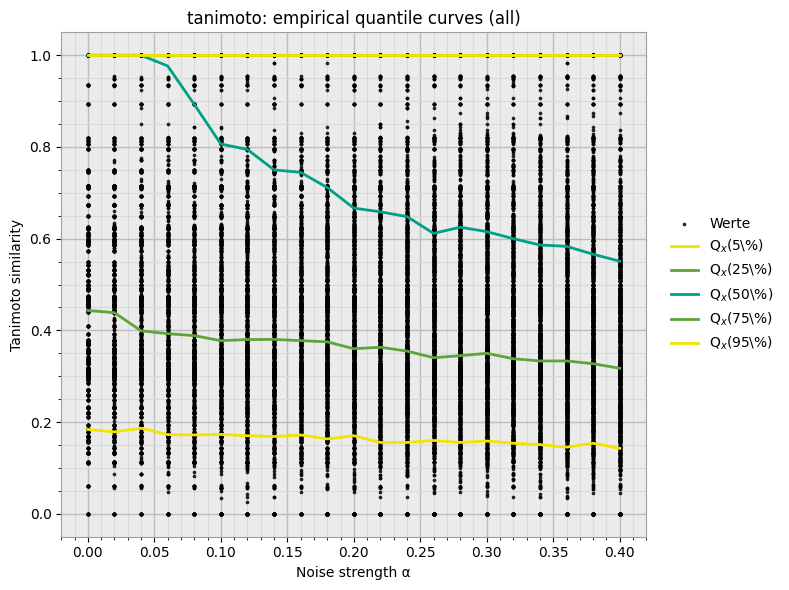

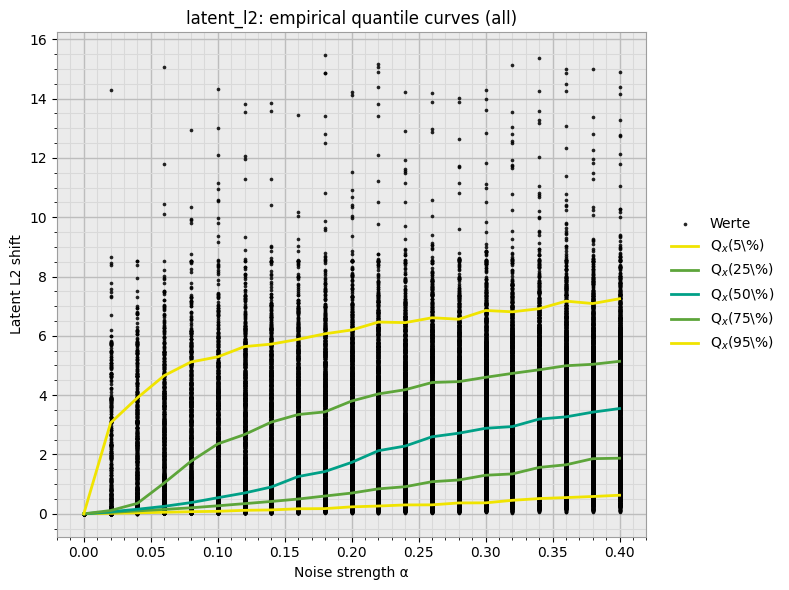

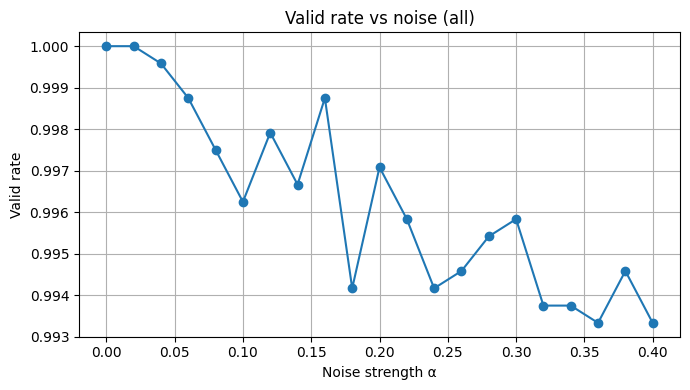

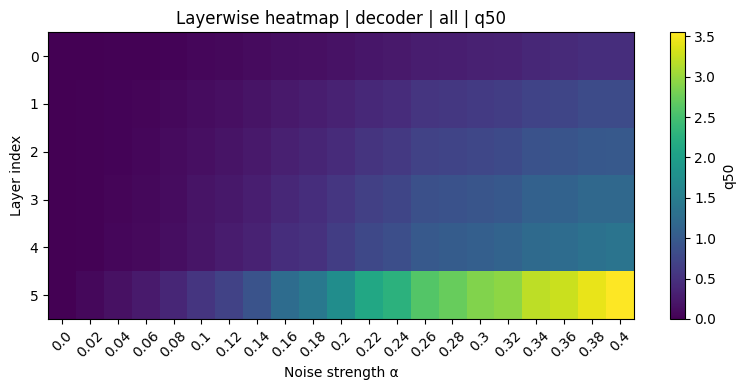

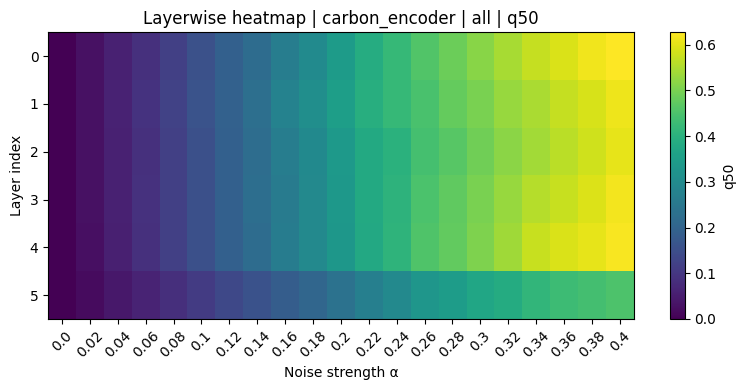

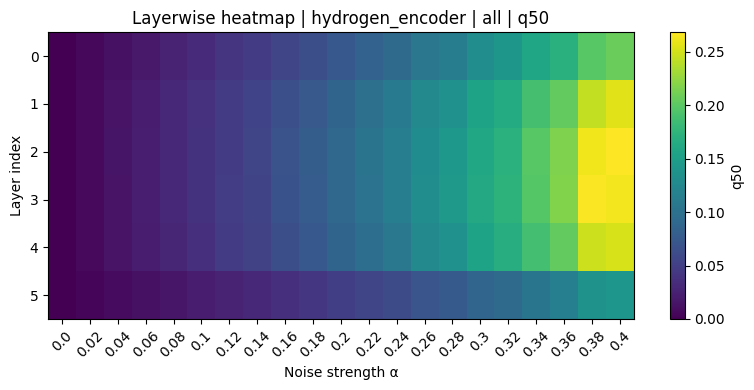

In [15]:
import sys, importlib
from pathlib import Path
import pandas as pd

sys.path.insert(0, "/mnt/data")
import noise_quantile_experiment as nqe
importlib.reload(nqe)

results_dir = Path("results")

sample_long_df = pd.read_csv(results_dir / "sample_long_df_all.csv")
layerwise_long_df = pd.read_csv(results_dir / "layerwise_long_df_all.csv")
tanimoto_summary = pd.read_csv(results_dir / "tanimoto_summary_all.csv")
latent_summary = pd.read_csv(results_dir / "latent_summary_all.csv")
valid_summary = pd.read_csv(results_dir / "valid_summary_all.csv")
layerwise_summary = pd.read_csv(results_dir / "layerwise_summary_all.csv")

# 1) Tanimoto: scatter + quantile curves
nqe.plot_quantile_scatter_style(
    long_df=sample_long_df,
    metric="tanimoto",
    noise_mode="all",
    quantiles=(0.05, 0.25, 0.5, 0.75, 0.95),
    ylabel="Tanimoto similarity",
)

# 2) Latent L2: scatter + quantile curves
nqe.plot_quantile_scatter_style(
    long_df=sample_long_df,
    metric="latent_l2",
    noise_mode="all",
    quantiles=(0.05, 0.25, 0.5, 0.75, 0.95),
    ylabel="Latent L2 shift",
)

# 3) Valid rate
nqe.plot_binary_rate(
    valid_summary,
    metric_name="Valid rate",
    noise_mode="all",
)

# 4) Layerwise heatmaps
nqe.plot_layerwise_heatmap(
    layerwise_summary,
    component="decoder",
    noise_mode="all",
    value_col="q50",
)

nqe.plot_layerwise_heatmap(
    layerwise_summary,
    component="carbon_encoder",
    noise_mode="all",
    value_col="q50",
)

nqe.plot_layerwise_heatmap(
    layerwise_summary,
    component="hydrogen_encoder",
    noise_mode="all",
    value_col="q50",
)